In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Load metadata and collapse to unique individuals
metadata = pd.read_parquet('/home/adm808/New_CellMetadataSyn1848517.parquet')
individuals = metadata.drop_duplicates("projid")

# Define AD status
individuals["cerad_ad"] = individuals["ceradsc"].isin([1, 2]).astype(int)
individuals["dcfdx_ad"] = individuals["dcfdx_lv"].isin([4.0, 5.0]).astype(int)

# Group and label
summary = individuals.groupby(["cerad_ad", "dcfdx_ad"]).size().reset_index(name="count")
summary["cerad_label"] = summary["cerad_ad"].map({0: "Pathology: Control", 1: "Pathology: AD"})
summary["dcfdx_label"] = summary["dcfdx_ad"].map({0: "Clinical: Control", 1: "Clinical: AD"})

print(summary[["cerad_label", "dcfdx_label", "count"]])

# Grid values and labels
labels = [["20", "4"], ["6", "18"]]
row_labels = ["Pathology: Control", "Pathology: AD"]
row_vars = ["", "Moderate or Frequent Neuritic Plaque"]
col_labels = ["Clinical: Control", "Clinical: AD"]
col_vars = ["", "AD Cogntive Impairment"]
colors = [["#c6dbef", "#d9d9d9"], ["#d9d9d9", "#fcbba1"]]

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

# Draw squares and numbers
for i in range(2):
    for j in range(2):
        rect = patches.Rectangle((j, 1 - i), 1, 1, linewidth=1.5, edgecolor='black', facecolor=colors[i][j])
        ax.add_patch(rect)
        ax.text(j + 0.5, 1 - i + 0.5, labels[i][j],
                va='center', ha='center', fontsize=22, fontweight='bold', color='black')

# Add row labels with variable
for i, row_label in enumerate(row_labels):
    ax.text(-0.15, 1 - i + 0.5, f"{row_label}\n{row_vars[i]}", va='center', ha='right', fontsize=12)

# Add column labels with variable
for j, col_label in enumerate(col_labels):
    ax.text(j + 0.5, 2.05, f"{col_label}\n{col_vars[j]}", va='bottom', ha='center', fontsize=12)

# Style
ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_xticks([])
ax.set_yticks([])
ax.axis("off")

plt.tight_layout()
plt.savefig("figure1b_ad_labels_grid.png", dpi=600, bbox_inches='tight')
plt.show()

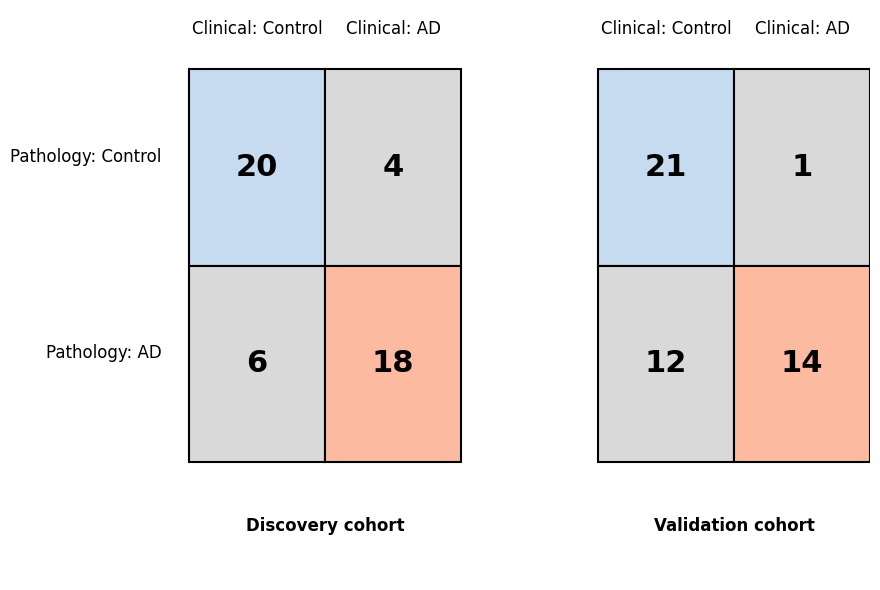

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# =========================================================
# Helper function (IDENTICAL logic)
# =========================================================
def make_summary(individuals):
    individuals = individuals.drop_duplicates("projid").copy()
    individuals["cerad_ad"] = individuals["ceradsc"].isin([1, 2]).astype(int)
    individuals["dcfdx_ad"] = individuals["dcfdx_lv"].isin([4.0, 5.0]).astype(int)

    summary = (
        individuals
        .groupby(["cerad_ad", "dcfdx_ad"])
        .size()
        .reset_index(name="count")
    )

    grid = [[0, 0], [0, 0]]
    for _, r in summary.iterrows():
        grid[r["cerad_ad"]][r["dcfdx_ad"]] = r["count"]
    return grid


# =========================================================
# Load datasets
# =========================================================
meta_disc = pd.read_parquet("/home/adm808/New_CellMetadataSyn1848517.parquet")
meta_val  = pd.read_csv("/n/scratch/users/a/adm808/Downloads/PFC_metadata_with_clinical.csv")

grid_disc = make_summary(meta_disc)
grid_val  = make_summary(meta_val)


# =========================================================
# Labels + colors (UNCHANGED style)
# =========================================================
row_labels = ["Pathology: Control", "Pathology: AD"]
row_vars   = ["", ""]
col_labels = ["Clinical: Control", "Clinical: AD"]
col_vars   = ["", ""]

colors = [["#c6dbef", "#d9d9d9"],
          ["#d9d9d9", "#fcbba1"]]


# =========================================================
# Plot
# =========================================================
fig, ax = plt.subplots(figsize=(9, 6))

def draw_box(grid, x_offset):
    for i in range(2):
        for j in range(2):
            rect = patches.Rectangle(
                (x_offset + j, 1 - i),
                1, 1,
                linewidth=1.5,
                edgecolor="black",
                facecolor=colors[i][j]
            )
            ax.add_patch(rect)

            ax.text(
                x_offset + j + 0.5,
                1 - i + 0.5,
                str(grid[i][j]),
                va="center", ha="center",
                fontsize=22, fontweight="bold"
            )

# Draw discovery (left) and validation (right)
draw_box(grid_disc, x_offset=0)
draw_box(grid_val,  x_offset=3)

# =========================================================
# Row labels (left only)
# =========================================================
for i, label in enumerate(row_labels):
    ax.text(
        -0.2,
        1 - i + 0.5,
        f"{label}\n{row_vars[i]}",
        va="center", ha="right",
        fontsize=12
    )

# =========================================================
# Column labels (compact, duplicated for both boxes)
# =========================================================
for j, label in enumerate(col_labels):
    ax.text(j + 0.5, 2.05,
            f"{label}\n{col_vars[j]}",
            va="bottom", ha="center", fontsize=12)

    ax.text(3 + j + 0.5, 2.05,
            f"{label}\n{col_vars[j]}",
            va="bottom", ha="center", fontsize=12)

# Box titles
ax.text(1, -0.35, "Discovery cohort", ha="center", fontsize=12, fontweight="bold")
ax.text(4, -0.35, "Validation cohort", ha="center", fontsize=12, fontweight="bold")

# =========================================================
# Styling
# =========================================================
ax.set_xlim(-0.8, 5)
ax.set_ylim(-0.6, 2.3)
ax.set_xticks([])
ax.set_yticks([])
ax.axis("off")

plt.tight_layout()
plt.savefig("/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/Figure_8/figure_ad_labels_discovery_validation.png", dpi=600, bbox_inches="tight")
plt.show()